<a href="https://colab.research.google.com/github/samuel76-art/Disciplina-de-Inteligencia-Artificial-UMC/blob/main/Atividade_FishMorphDB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import kagglehub
path = kagglehub.dataset_download("menegidio/fishmorph-dataset")

Using Colab cache for faster access to the 'fishmorph-dataset' dataset.


In [7]:
import os

df = pd.read_csv(os.path.join(path, "FISHMORPH_Order_Dataset.csv"))
# df = pd.read_csv(os.path.join(path, "FISHMORPH_Family_Dataset.csv"))

print(df.shape)
df.head()

(8342, 11)


,MBl,BEl,VEp,REs,OGp,RMl,BLs,PFv,PFs,CPt,Order
0,130.0,4.579113,0.622642,0.375019,0.622642,0.868659,0.484981,0.273585,0.144108,3.348991,Cypriniformes
1,11.5,2.796068,0.650700,0.353780,0.509800,0.411157,0.722461,0.330169,0.221095,2.525592,Perciformes
2,6.6,4.564329,0.518187,0.312002,0.203985,0.413221,0.591495,0.105517,0.188193,2.104580,Cypriniformes
3,10.9,4.390422,0.548247,0.244804,0.168959,0.324728,0.642991,0.097450,0.193049,1.787062,Cypriniformes
4,18.9,4.410271,0.542353,0.292058,0.183790,0.398567,0.685672,0.087643,0.170648,2.968906,Cypriniformes


In [8]:
df.info()
print("\nNulos por coluna:")
print(df.isnull().sum())
print("\nDuplicados:", df.duplicated().sum())
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8342 entries, 0 to 8341
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   MBl     8342 non-null   float64
 1   BEl     8342 non-null   float64
 2   VEp     8342 non-null   float64
 3   REs     8342 non-null   float64
 4   OGp     8342 non-null   float64
 5   RMl     8342 non-null   float64
 6   BLs     8342 non-null   float64
 7   PFv     8342 non-null   float64
 8   PFs     8342 non-null   float64
 9   CPt     8342 non-null   float64
 10  Order   8342 non-null   object 
dtypes: float64(10), object(1)
memory usage: 717.0+ KB

Nulos por coluna:
MBl      0
BEl      0
VEp      0
REs      0
OGp      0
RMl      0
BLs      0
PFv      0
PFs      0
CPt      0
Order    0
dtype: int64

Duplicados: 1


,MBl,BEl,VEp,REs,OGp,RMl,BLs,PFv,PFs,CPt
count,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000
mean,22.004517,4.452438,0.549087,0.391665,0.381768,0.399786,0.571818,0.285316,0.189343,2.560795
std,33.612007,2.338235,0.094883,0.132814,0.194352,0.302658,0.117486,0.155629,0.056109,1.016659
min,1.200000,1.033084,0.159248,0.000000,0.000000,0.000000,0.224525,0.000000,0.000000,0.000000
25%,7.000000,3.139102,0.487993,0.293205,0.278014,0.257999,0.490052,0.193134,0.157972,1.999744
50%,12.600000,4.038851,0.546213,0.389429,0.406904,0.361436,0.564739,0.275039,0.183497,2.436329
75%,24.500000,5.002621,0.605125,0.486221,0.516001,0.490671,0.648039,0.368876,0.215031,2.919818
max,800.000000,43.728161,1.000000,1.026667,1.026316,7.060344,1.230105,0.857097,0.511113,15.452061


In [9]:
print(df.columns.tolist())

TARGET = df.columns[-1]   # confirme se é a coluna certa
print("Alvo:", TARGET)

['MBl', 'BEl', 'VEp', 'REs', 'OGp', 'RMl', 'BLs', 'PFv', 'PFs', 'CPt', 'Order']
Alvo: Order


In [10]:
# Remove nulos e duplicados
df = df.dropna().drop_duplicates().reset_index(drop=True)

# Mantém só colunas numéricas como features
X = df.drop(columns=[TARGET]).select_dtypes(include=[np.number])
y = df[TARGET]

print("Features usadas:", X.columns.tolist())
print("Shape:", X.shape)

Features usadas: ['MBl', 'BEl', 'VEp', 'REs', 'OGp', 'RMl', 'BLs', 'PFv', 'PFs', 'CPt']
Shape: (8341, 10)


Order
Cypriniformes         1933
Perciformes           1826
Siluriformes          1800
Characiformes         1281
Cyprinodontiformes     554
Osteoglossiformes      156
Clupeiformes           104
Gymnotiformes          101
Salmoniformes           92
Atheriniformes          71
Scorpaeniformes         70
Osmeriformes            69
Synbranchiformes        48
Beloniformes            33
Tetraodontiformes       31
Pleuronectiformes       28
Acipenseriformes        23
Mugiliformes            18
Syngnathiformes         16
Anguilliformes          16
Gasterosteiformes       13
Gonorynchiformes        10
Esociformes             10
Polypteriformes          9
Lepisosteiformes         6
Percopsiformes           6
Elopiformes              5
Batrachoidiformes        4
Gadiformes               3
Gobiesociformes          3
Amiiformes               1
Ophidiiformes            1
Name: count, dtype: int64


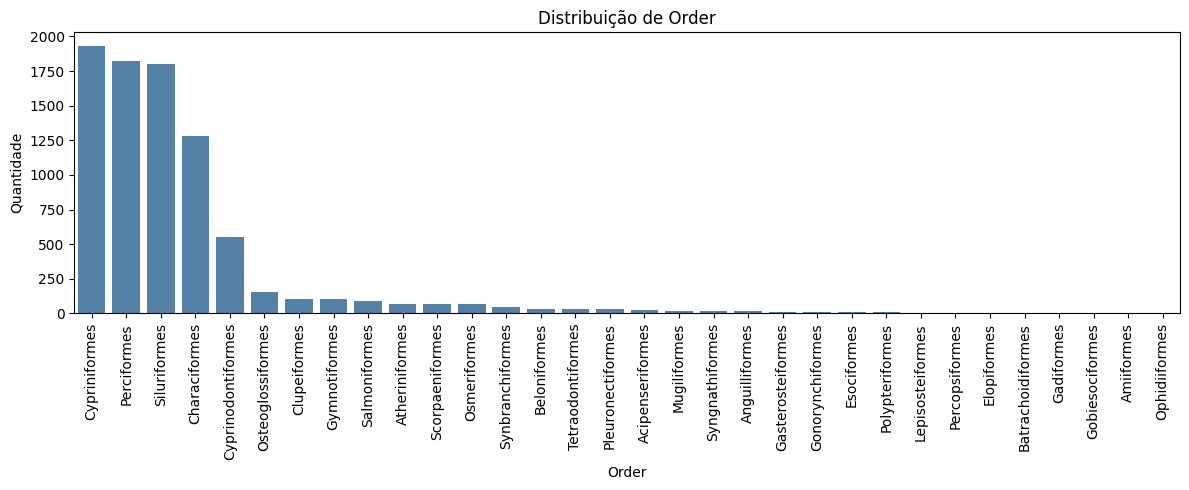

In [11]:
contagem = y.value_counts()
print(contagem)

plt.figure(figsize=(12, 5))
sns.barplot(x=contagem.index, y=contagem.values, color="steelblue")
plt.xticks(rotation=90)
plt.title(f"Distribuição de {TARGET}")
plt.ylabel("Quantidade")
plt.tight_layout()
plt.show()

In [12]:
MIN_AMOSTRAS = 10
validas = contagem[contagem >= MIN_AMOSTRAS].index
mask = y.isin(validas)
X, y = X[mask], y[mask]

print(f"Classes mantidas: {len(validas)} | Amostras: {len(y)}")

Classes mantidas: 23 | Amostras: 8303


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC())
])

param_grid = {
    "svm__kernel": ["linear", "poly", "rbf", "sigmoid"],
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": [0.001, 0.01, 0.1, 1],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipe, param_grid, cv=cv, scoring="accuracy",
    n_jobs=-1, verbose=1
)
grid.fit(X_train, y_train)

Fitting 5 folds for each of 64 candidates, totalling 320 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svm', SVC())]),
             n_jobs=-1,
             param_grid={'svm__C': [0.1, 1, 10, 100],
                         'svm__gamma': [0.001, 0.01, 0.1, 1],
                         'svm__kernel': ['linear', 'poly', 'rbf', 'sigmoid']},
             scoring='accuracy', verbose=1)

In [14]:
melhor = grid.best_estimator_
y_pred = melhor.predict(X_test)

print("Modelo: SVM (SVC)")
print("Melhores parâmetros:", grid.best_params_)
print(f"Acurácia média no cross validation (treino): {grid.best_score_:.4f}")
print(f"Acurácia no teste: {accuracy_score(y_test, y_pred):.4f}")
print("\n", classification_report(y_test, y_pred, zero_division=0))

Modelo: SVM (SVC)
Melhores parâmetros: {'svm__C': 10, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}
Acurácia média no cross validation (treino): 0.7919
Acurácia no teste: 0.8176

                     precision    recall  f1-score   support

  Acipenseriformes       1.00      0.80      0.89         5
    Anguilliformes       1.00      0.67      0.80         3
    Atheriniformes       0.75      0.86      0.80        14
      Beloniformes       1.00      0.86      0.92         7
     Characiformes       0.78      0.77      0.78       256
      Clupeiformes       0.62      0.38      0.47        21
     Cypriniformes       0.72      0.79      0.75       387
Cyprinodontiformes       0.89      0.84      0.87       111
       Esociformes       1.00      0.50      0.67         2
 Gasterosteiformes       1.00      0.50      0.67         2
  Gonorynchiformes       0.00      0.00      0.00         2
     Gymnotiformes       0.95      1.00      0.98        20
      Mugiliformes       0.75      0.75     

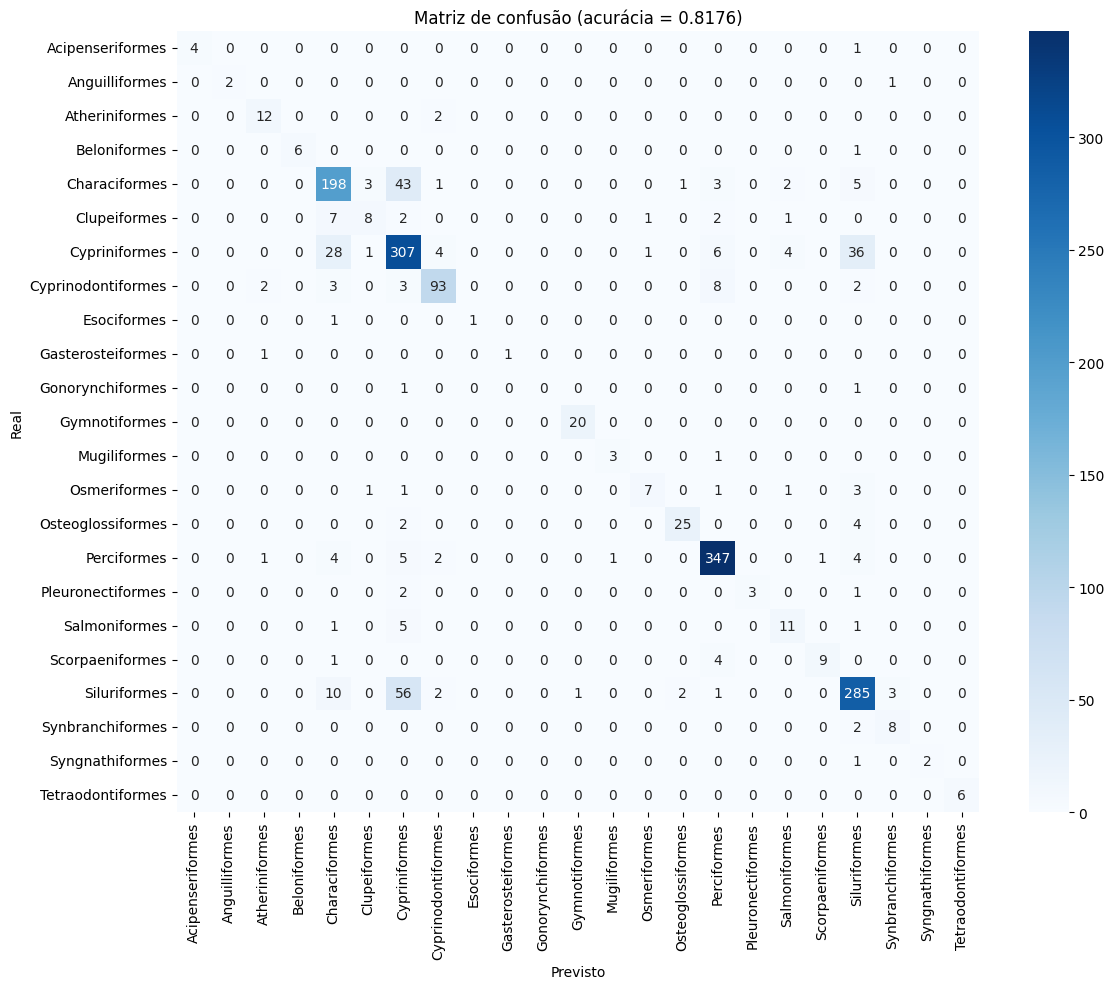

In [15]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title(f"Matriz de confusão (acurácia = {accuracy_score(y_test, y_pred):.4f})")
plt.tight_layout()
plt.show()